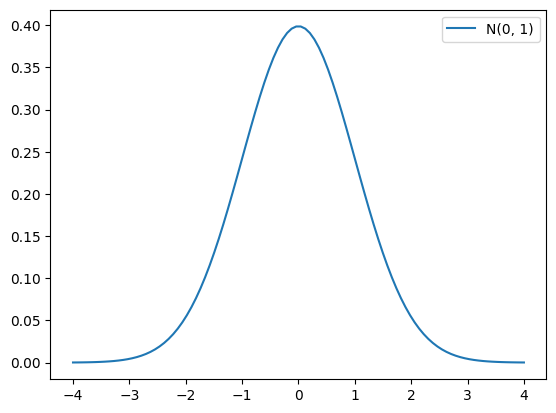

In [1]:
from scipy.stats import norm         # для работы с нормальным распределением
import numpy as np                      # для создания массива чисел
import matplotlib.pyplot as plt       # для построения графиков

x = np.linspace(-4, 4, 100)            # Генерирует 100 точек в диапазоне от −4 до 4.
pdf = norm.pdf(x, loc=0, scale=1) # вычисление плотности вероятности
plt.plot(x, pdf, label="N(0, 1)")      # рисует кривую
plt.legend()                                   # добавляет легенду
plt.show()                                     # отображает график

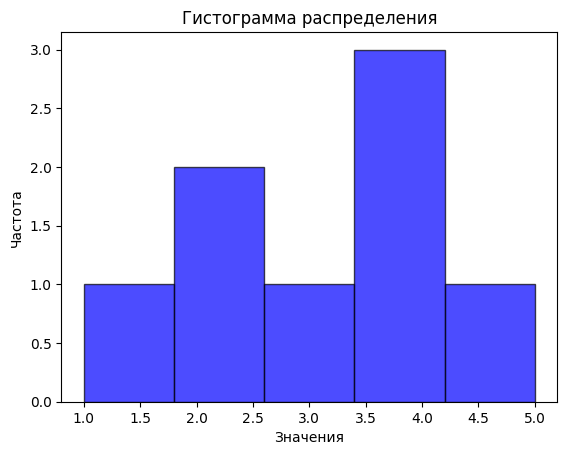

In [2]:
import matplotlib.pyplot as plt     # импортируем библиотеку
data = [1, 2, 2, 3, 4, 4, 4, 5]     # определяем массив данных
plt.hist(data, bins=5, alpha=0.7, color='blue', edgecolor='black') # рисуем гистограмму с 5 бинами, прозрачность столбцов 0.7, цвет заливки синий и границ - черный
plt.title("Гистограмма распределения") # название графика

#подписи осей
plt.xlabel("Значения")
plt.ylabel("Частота")
plt.show()

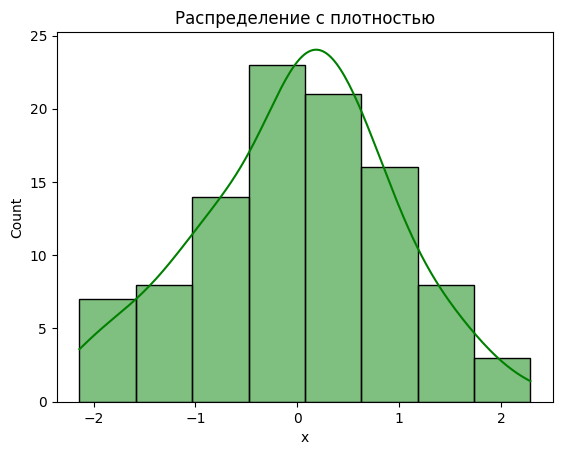

In [3]:
import seaborn as sns # импорт библиотек
import pandas as pd
#создаем датафрейм из 100 случайных чисел, взятых из стандартного нормального распределения
data = pd.DataFrame({'x': np.random.normal(size=100)})
#Построение гистограммы с KDE (Kernel Density Estimation) — гладкую кривую плотности.
sns.histplot(data['x'], kde=True, color='green')
plt.title("Распределение с плотностью")
plt.show()

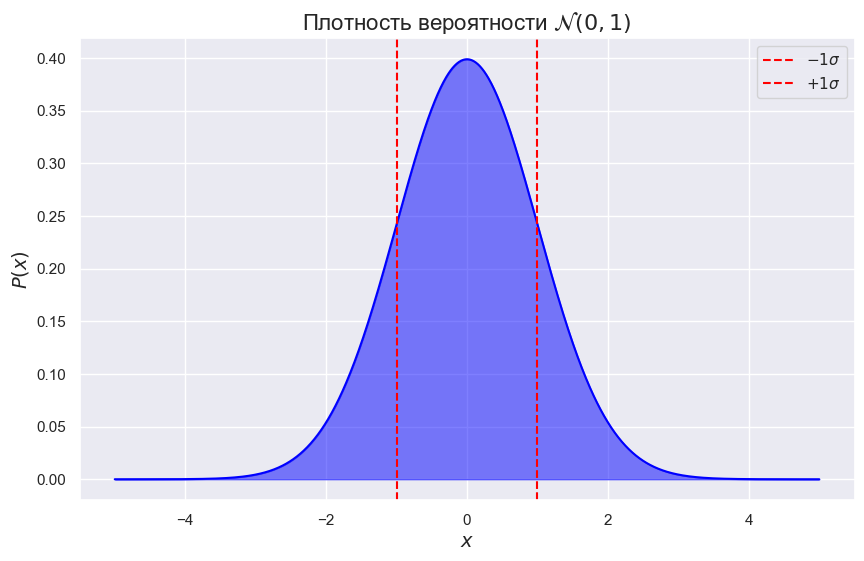

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 4. Устанавливаем стиль Seaborn
sns.set_theme()

# Данные: интервал [-5; 5]
x = np.linspace(-5, 5, 1000)

# Вычисляем плотность вероятности нормального распределения N(0, 1)
# loc=0 (среднее), scale=1 (стандартное отклонение)
y = stats.norm.pdf(x, loc=0, scale=1)

# Создаем график
plt.figure(figsize=(10, 6))

# Рисуем линию графика (опционально, для четкости контура)
plt.plot(x, y, color='blue')

# 1. Заполнение области под кривой с прозрачностью 50% (alpha=0.5)
plt.fill_between(x, y, color='blue', alpha=0.5)

# 2. Вертикальные линии на ±1σ пунктиром
# Так как распределение N(0, 1), то сигма равна 1
plt.axvline(x=-1, color='red', linestyle='--', label=r'$-1\sigma$')
plt.axvline(x=1, color='red', linestyle='--', label=r'$+1\sigma$')

# 3. Подписи осей и заголовок в LaTeX-формате
plt.title(r'Плотность вероятности $\mathcal{N}(0, 1)$', fontsize=16)
plt.xlabel(r'$x$', fontsize=14)
plt.ylabel(r'$P(x)$', fontsize=14)

# Добавляем легенду (не обязательно по заданию, но полезно)
plt.legend()

# Отображаем график
plt.show()


Разбор выполнения требований:

stats.norm.pdf(x, loc=0, scale=1): Используется модуль stats библиотеки SciPy для расчета значений.

plt.fill_between(..., alpha=0.5): Заливает область под графиком, параметр alpha=0.5 дает требуемую прозрачность 50%.

plt.axvline(..., linestyle='--'): Рисует вертикальные линии, стиль '--' делает их пунктирными.

r'$\mathcal{N}(0, 1)$': Использование r'$...$' позволяет Matplotlib интерпретировать текст как формулы LaTeX.

sns.set_theme(): Включает стандартную сетку и стилизацию от Seaborn.

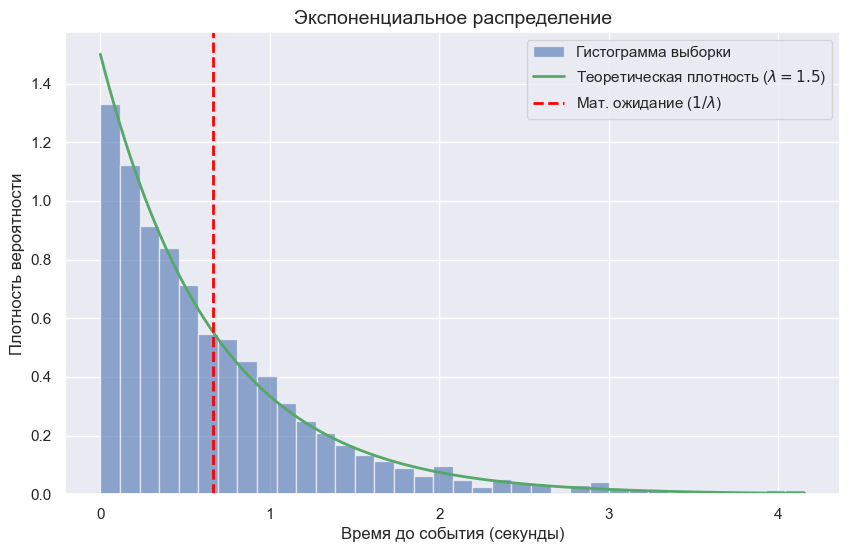

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# (Опционально) Включаем красивый стиль, как в прошлом задании
sns.set_theme()

# 1. Параметры
lambd = 1.5
scale = 1 / lambd  # В scipy scale = 1 / lambda
size = 2000

# Генерируем выборку из 2000 значений
# Можно использовать stats.expon.rvs или np.random.exponential
data = stats.expon.rvs(scale=scale, size=size)

# Создаем график
plt.figure(figsize=(10, 6))

# 2. Гистограмма с автоматическим подбором бинов
# Важно: density=True, чтобы график нормировался к плотности вероятности (иначе он будет по оси Y показывать количество, а не вероятность)
plt.hist(data, bins='auto', density=True, alpha=0.6, label='Гистограмма выборки')

# 3. Теоретическая плотность распределения
x = np.linspace(0, np.max(data), 1000)
pdf = stats.expon.pdf(x, scale=scale)
plt.plot(x, pdf, 'g-', lw=2, label=r'Теоретическая плотность ($\lambda=1.5$)')

# 4. Вертикальная линия на математическом ожидании (1 / lambda)
mean_val = 1 / lambd
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=r'Мат. ожидание ($1/\lambda$)')

# 5. Легенда и подписи
plt.xlabel("Время до события (секунды)", fontsize=12)
plt.ylabel("Плотность вероятности", fontsize=12)
plt.title("Экспоненциальное распределение", fontsize=14)
plt.legend()

plt.show()


Обратите внимание на важный момент: в библиотеке scipy у экспоненциального распределения параметр scale равен обратному значению лямбда (scale = 1 / lambda). Если поставить туда просто 1.5, результат будет неверным.

Пояснения к коду:
scale = 1 / lambd: Это ключевой момент. Математическое ожидание экспоненциального распределения равно $1/\lambda$, и именно это значение библиотека SciPy принимает за параметр масштаба (scale).

density=True: В функции plt.hist этот параметр обязателен, если вы хотите наложить сверху теоретическую кривую. Он превращает абсолютные значения (штуки) в относительные (плотность), чтобы масштабы гистограммы и линии совпадали.

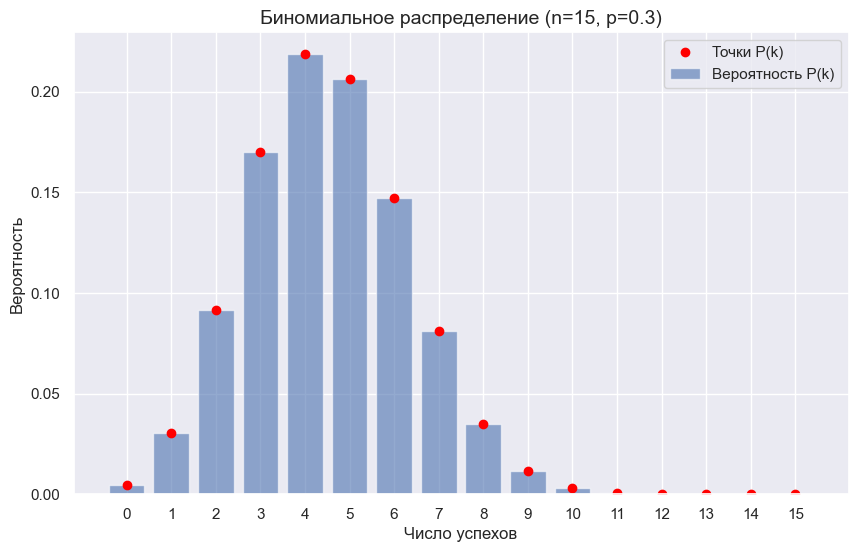

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# 1. Параметры распределения
n = 15
p = 0.3

# Создаем массив всех возможных значений k (от 0 до n включительно)
k_values = np.arange(0, n + 1)

# 2. Рассчитываем вероятности P(k) с помощью binom.pmf
# pmf = Probability Mass Function (функция вероятности для дискретных величин)
p_values = stats.binom.pmf(k_values, n, p)

# Создаем график
plt.figure(figsize=(10, 6))
sns.set_theme()  # Опционально для красоты

# 3. Строим столбчатую диаграмму
plt.bar(k_values, p_values, alpha=0.6, label='Вероятность P(k)')

# 4. Добавляем красные маркеры точек поверх столбцов
# Используем plt.plot, но только с маркерами ('o'), без линий
plt.plot(k_values, p_values, marker='o', color='red', linestyle='None', label='Точки P(k)')

# 5. Подписи осей
plt.xlabel("Число успехов", fontsize=12)
plt.ylabel("Вероятность", fontsize=12)
plt.title(f"Биномиальное распределение (n={n}, p={p})", fontsize=14)

# Дополнительно: делаем ось X целочисленной, так как успехов может быть только целое число
plt.xticks(k_values)

plt.legend()
plt.show()


Разбор ключевых моментов:

np.arange(0, n + 1): Важно добавить +1, так как функция arange не включает правую границу. Нам нужны значения от 0 до 15 включительно (всего 16 точек).

linestyle='None': В пункте 4, когда мы добавляем точки, нужно убрать соединительные линии, чтобы остались только "шарики" на вершинах столбцов.

plt.xticks: Для дискретных распределений (как биномиальное) хорошим тоном считается настроить ось X так, чтобы деления стояли ровно под каждым столбцом (0, 1, 2...), а не дробями.

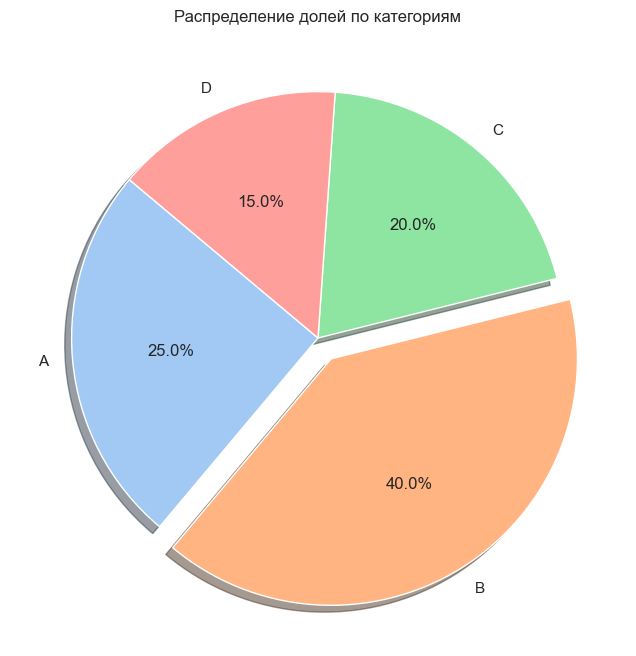

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Установка стиля Seaborn (как в задании)
sns.set_style("whitegrid")

# 2. Создаем DataFrame с данными
data = {
    'категории': ['A', 'B', 'C', 'D'],
    'доли': [25, 40, 20, 15]
}
df = pd.DataFrame(data)

# Настройка для отделения сектора "B"
# Порядок соответствует списку категорий: A, B, C, D.
# Значит, второй элемент должен быть 0.1
explode_config = [0, 0.1, 0, 0]

# Создаем фигуру
plt.figure(figsize=(8, 8))

# 3. Строим круговую диаграмму
plt.pie(
    df['доли'],                   # Данные
    labels=df['категории'],       # Подписи категорий
    autopct='%1.1f%%',            # Формат выносок с процентами (один знак после запятой)
    shadow=True,                  # Добавление тени
    explode=explode_config,       # Отделение сектора
    startangle=140,               # (Опционально) Поворот диаграммы для красоты
    colors=sns.color_palette('pastel') # (Опционально) Приятные цвета из палитры Seaborn
)

# Заголовок
plt.title('Распределение долей по категориям')

# Отображаем график
plt.show()


Важные моменты:

autopct='%1.1f%%': Эта строка отвечает за автоматический подсчет и отображение процентов на дольках.

explode=[0, 0.1, 0, 0]: Массив должен быть той же длины, что и данные. Значение 0.1 на второй позиции «выдвигает» второй сектор (в нашем случае "B") из круга.

pd.DataFrame: В задании явно просят создать DataFrame, поэтому мы сначала упаковываем списки в словарь data, а потом создаем из него df. Хотя plt.pie может принимать и обычные списки, использование pandas — часть условия.

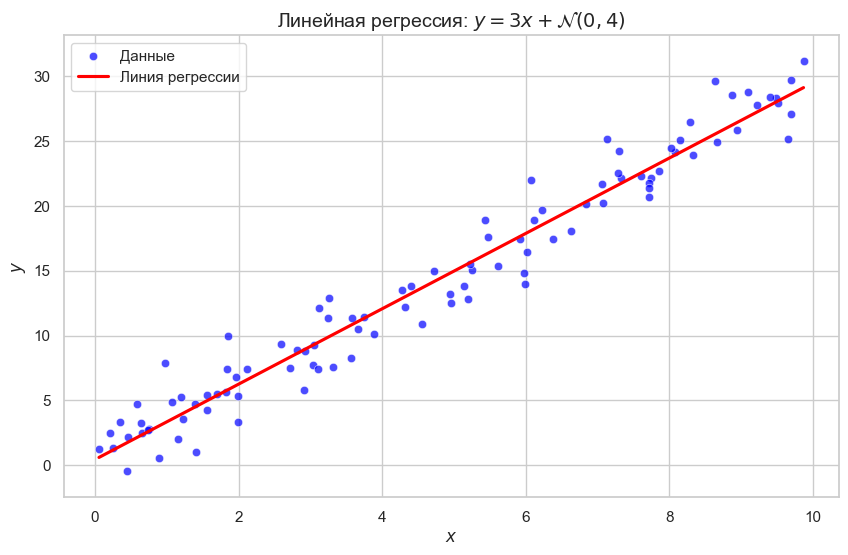

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля (опционально, для красоты)
sns.set_theme(style="whitegrid")

# 1. Генерация данных
np.random.seed(42) # Для воспроизводимости результатов
n_points = 100

# x ~ U[0, 10] - Равномерное распределение
x = np.random.uniform(0, 10, n_points)

# y = 3x + e, где e ~ N(0, 4).
# В обозначении N(0, 4) число 4 — это обычно дисперсия (sigma^2).
# Значит, стандартное отклонение sigma = sqrt(4) = 2.
epsilon = np.random.normal(loc=0, scale=2, size=n_points)
y = 3 * x + epsilon

# Создаем фигуру
plt.figure(figsize=(10, 6))

# 2. Точечный график (scatterplot) с прозрачностью
sns.scatterplot(x=x, y=y, alpha=0.7, color='blue', label='Данные')

# 3. Линия регрессии без доверительного интервала (ci=None)
# regplot сам рисует и точки, и линию, но в задании просят добавить линию к scatterplot.
# Мы используем regplot с параметром scatter=False, чтобы нарисовать только линию поверх.
sns.regplot(x=x, y=y, scatter=False, ci=None, color='red', label='Линия регрессии')

# 4. Подписи осей в формате LaTeX
plt.title(r'Линейная регрессия: $y = 3x + \mathcal{N}(0, 4)$', fontsize=14)
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$y$', fontsize=12)

# 5. Ограничение по оси Y: [min(y) - 2, max(y) + 2]
plt.ylim(np.min(y) - 2, np.max(y) + 2)

# Легенда
plt.legend()

# Показать график
plt.show()


В этом задании есть важный нюанс: обозначение $N(0, 4)$ в математике часто означает дисперсию $\sigma^2 = 4$, то есть стандартное отклонение $\sigma = 2$. Однако в коде Python (np.random.normal) параметр scale принимает именно стандартное отклонение. Я использовал scale=2 (так как $\sqrt{4}=2$), что является стандартной интерпретацией таких учебных задач.

Пояснения к коду:

np.random.uniform(0, 10, 100): Генерирует 100 точек, равномерно разбросанных от 0 до 10.

np.random.normal(loc=0, scale=2): Генерирует шум. Важно: scale — это стандартное отклонение. Если в условии $N(0, 4)$ четверка — это дисперсия, то scale должен быть равен 2.

sns.regplot(..., ci=None): Параметр ci=None (Confidence Interval) отключает полупрозрачную тень вокруг линии, как и требовалось в задании («без отображения доверительного интервала»).

plt.ylim(...): Жестко задает границы графика по вертикали, добавляя отступ в 2 единицы сверху и снизу от крайних точек.

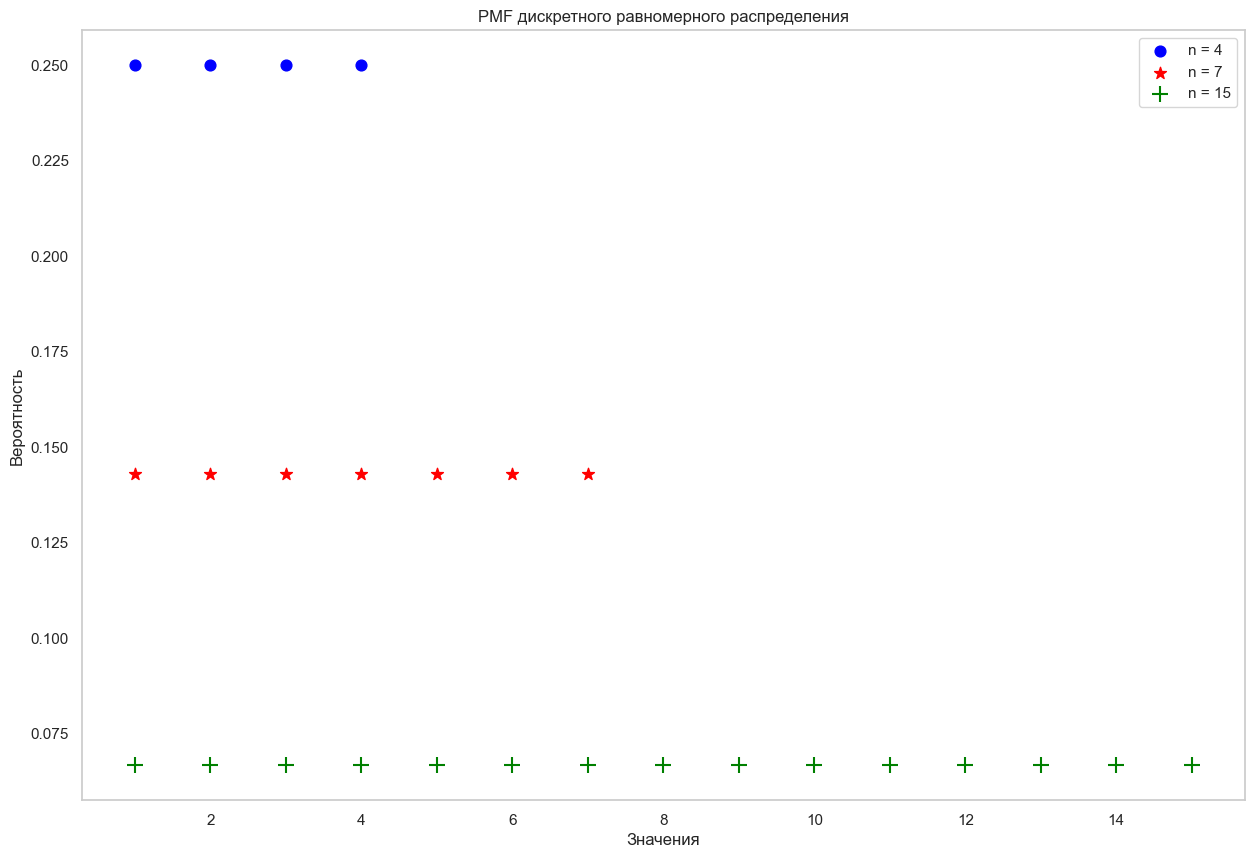

In [9]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import randint         	# Импортируем метод randint
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем диапазоны значений
x1 = np.arange(1, 5)                    	# Значения для n = 4
x2 = np.arange(1, 8)                    	# Значения для n = 7
x3 = np.arange(1, 16)                   	# Значения для n = 15

# Строим графики PMF
plt.scatter(x1, randint.pmf(x1, 1, 5), s=60, c="blue", marker="o", label='n = 4')
plt.scatter(x2, randint.pmf(x2, 1, 8), s=80, c="red", marker="*", label='n = 7')
plt.scatter(x3, randint.pmf(x3, 1, 16), s=120, c="green", marker="+", label='n = 15')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF дискретного равномерного распределения")
plt.xlabel("Значения")
plt.ylabel("Вероятность")
plt.show()

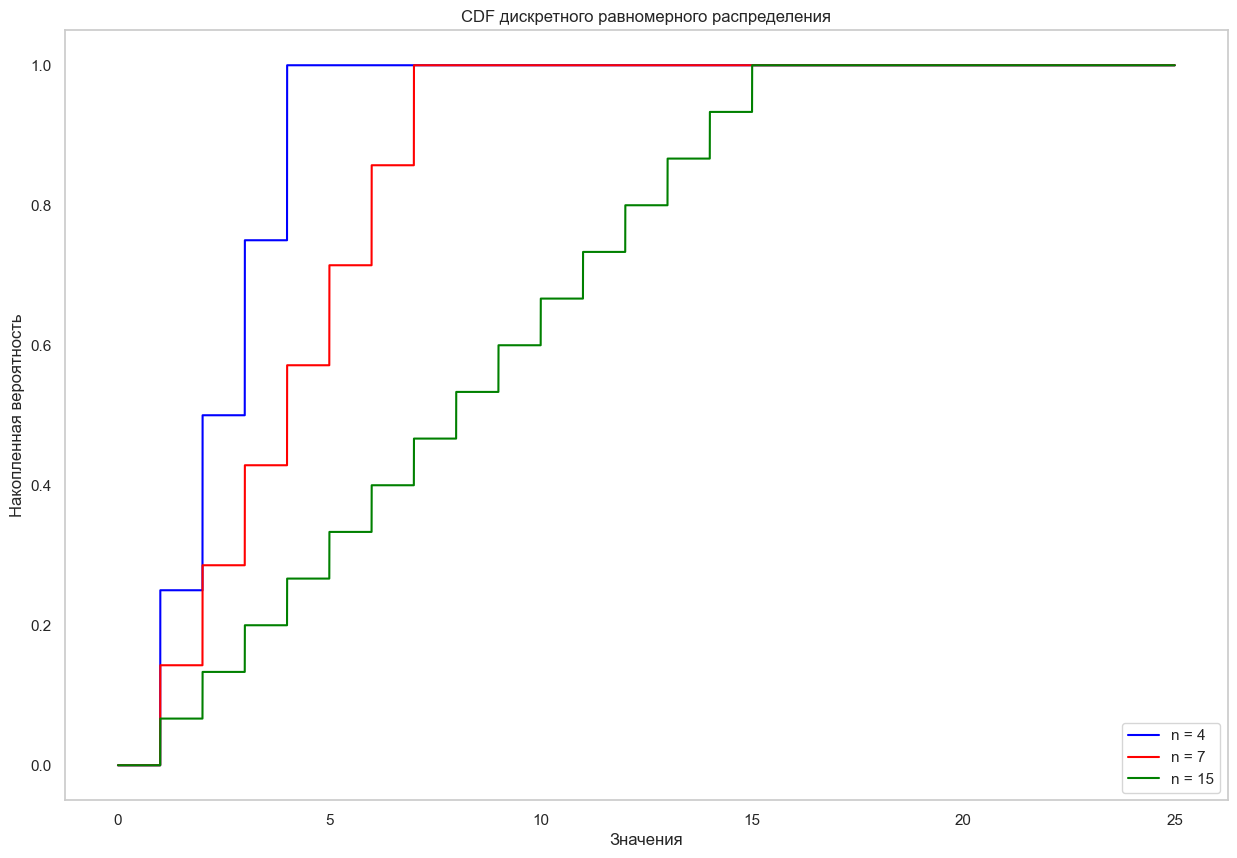

In [10]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import randint         	# Импортируем метод randint
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем диапазоны значений
x = np.arange(0, 25, 0.001)             	# Создаем массив чисел от 0 до 25 с шагом 0.001

# Строим графики CDF
plt.plot(x, randint.cdf(x, 1, 5), c="blue", label='n = 4')   # CDF для n = 4
plt.plot(x, randint.cdf(x, 1, 8), c="red", label='n = 7')	# CDF для n = 7
plt.plot(x, randint.cdf(x, 1, 16), c="green", label='n = 15') # CDF для n = 15

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower right')

# Отображаем график
plt.title("CDF дискретного равномерного распределения")
plt.xlabel("Значения")
plt.ylabel("Накопленная вероятность")
plt.show()

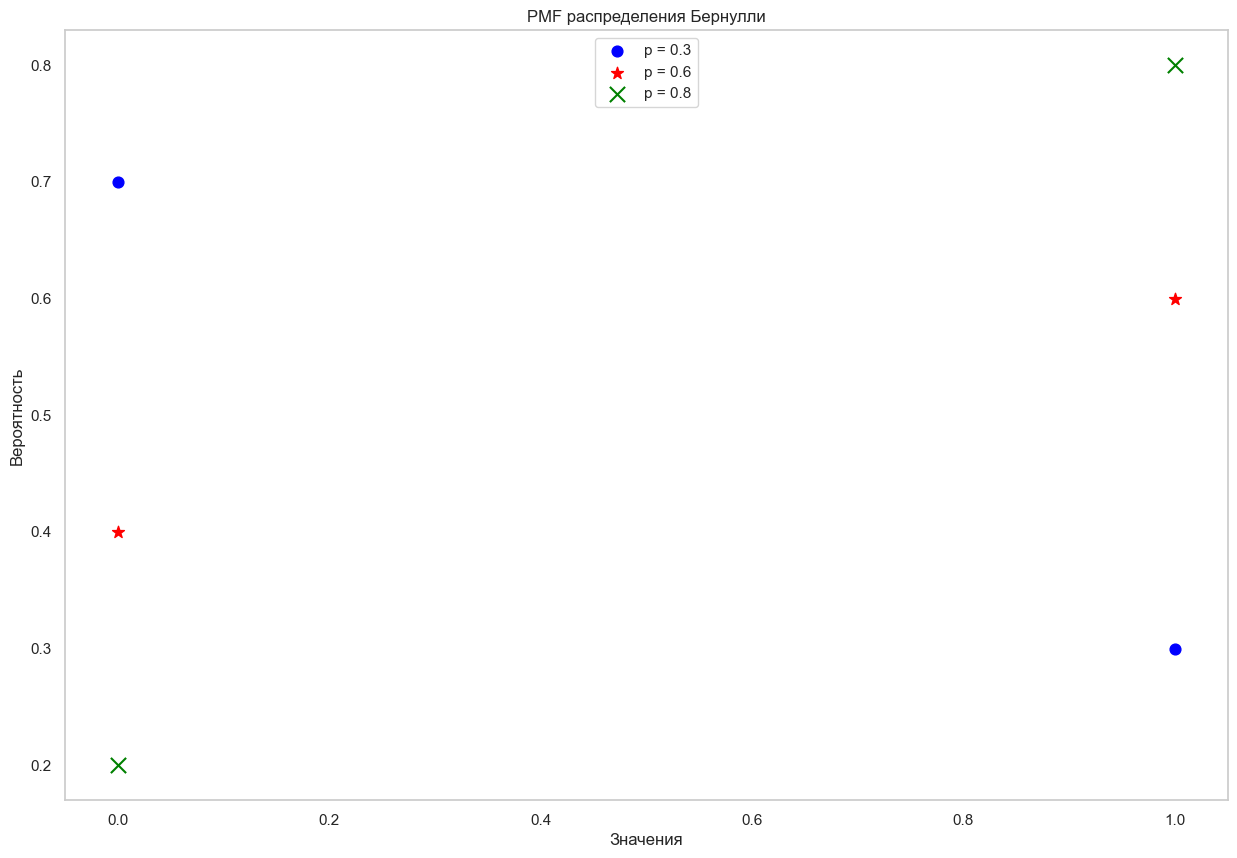

In [11]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import bernoulli       	# Импортируем метод bernoulli
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем диапазон значений
x = np.arange(0, 2)                     	# Значения 0 и 1

# Строим графики PMF
plt.scatter(x, bernoulli.pmf(x, 0.3), s=60, c="blue", marker="o", label='p = 0.3')
plt.scatter(x, bernoulli.pmf(x, 0.6), s=80, c="red", marker="*", label='p = 0.6')
plt.scatter(x, bernoulli.pmf(x, 0.8), s=120, c="green", marker="x", label='p = 0.8')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper center')

# Отображаем график
plt.title("PMF распределения Бернулли")
plt.xlabel("Значения")
plt.ylabel("Вероятность")
plt.show()

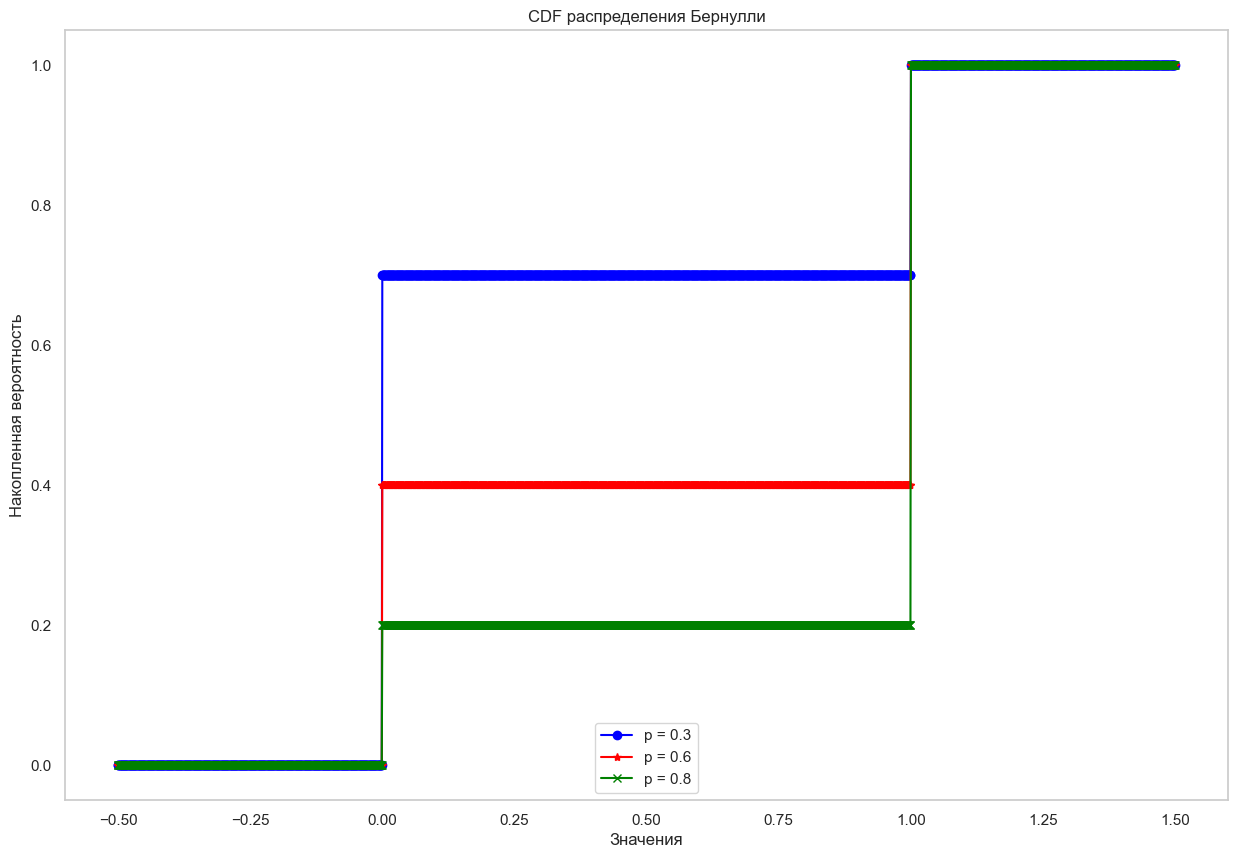

In [12]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import bernoulli       	# Импортируем метод bernoulli
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем диапазон значений
x = np.arange(-0.5, 1.5, 0.001)

# Строим графики CDF
plt.plot(x, bernoulli.cdf(x, 0.3), c="blue", marker="o", label='p = 0.3')
plt.plot(x, bernoulli.cdf(x, 0.6), c="red", marker="*", label='p = 0.6')
plt.plot(x, bernoulli.cdf(x, 0.8), c="green", marker="x", label='p = 0.8')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower center')

# Отображаем график
plt.title("CDF распределения Бернулли")
plt.xlabel("Значения")
plt.ylabel("Накопленная вероятность")
plt.show()

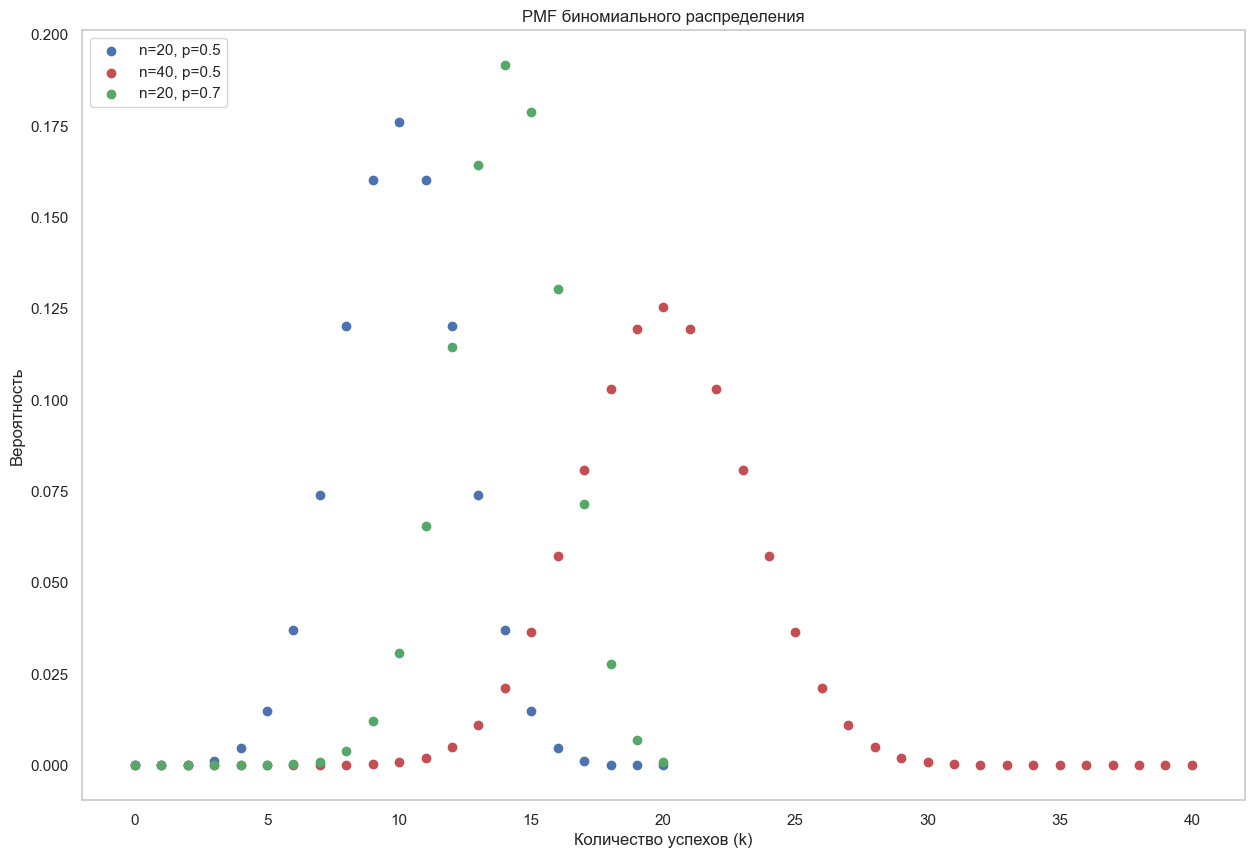

In [13]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем параметры
n, p = 20, 0.5
x = np.arange(0, n + 1)
plt.scatter(x, binom.pmf(x, n, p), c='b', label='n=20, p=0.5')

n, p = 40, 0.5
x = np.arange(0, n + 1)
plt.scatter(x, binom.pmf(x, n, p), c='r', label='n=40, p=0.5')

n, p = 20, 0.7
x = np.arange(0, n + 1)
plt.scatter(x, binom.pmf(x, n, p), c='g', label='n=20, p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper left')

# Отображаем график
plt.title("PMF биномиального распределения")
plt.xlabel("Количество успехов (k)")
plt.ylabel("Вероятность")
plt.show()

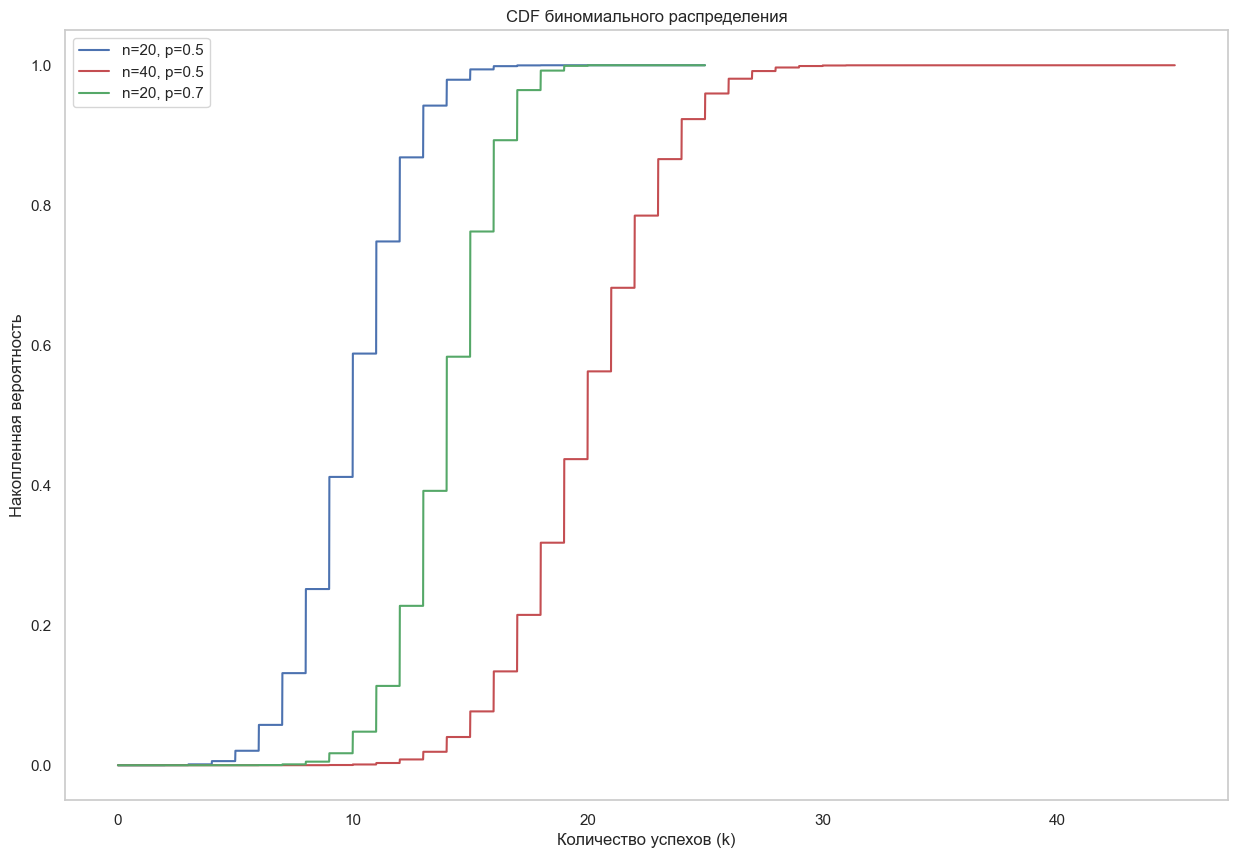

In [14]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем параметры
n, p = 20, 0.5
x = np.arange(0, n + 5, 0.01)
plt.plot(x, binom.cdf(x, n, p), c='b', label='n=20, p=0.5')

n, p = 40, 0.5
x = np.arange(0, n + 5, 0.01)
plt.plot(x, binom.cdf(x, n, p), c='r', label='n=40, p=0.5')

n, p = 20, 0.7
x = np.arange(0, n + 5, 0.01)
plt.plot(x, binom.cdf(x, n, p), c='g', label='n=20, p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper left')

# Отображаем график
plt.title("CDF биномиального распределения")
plt.xlabel("Количество успехов (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

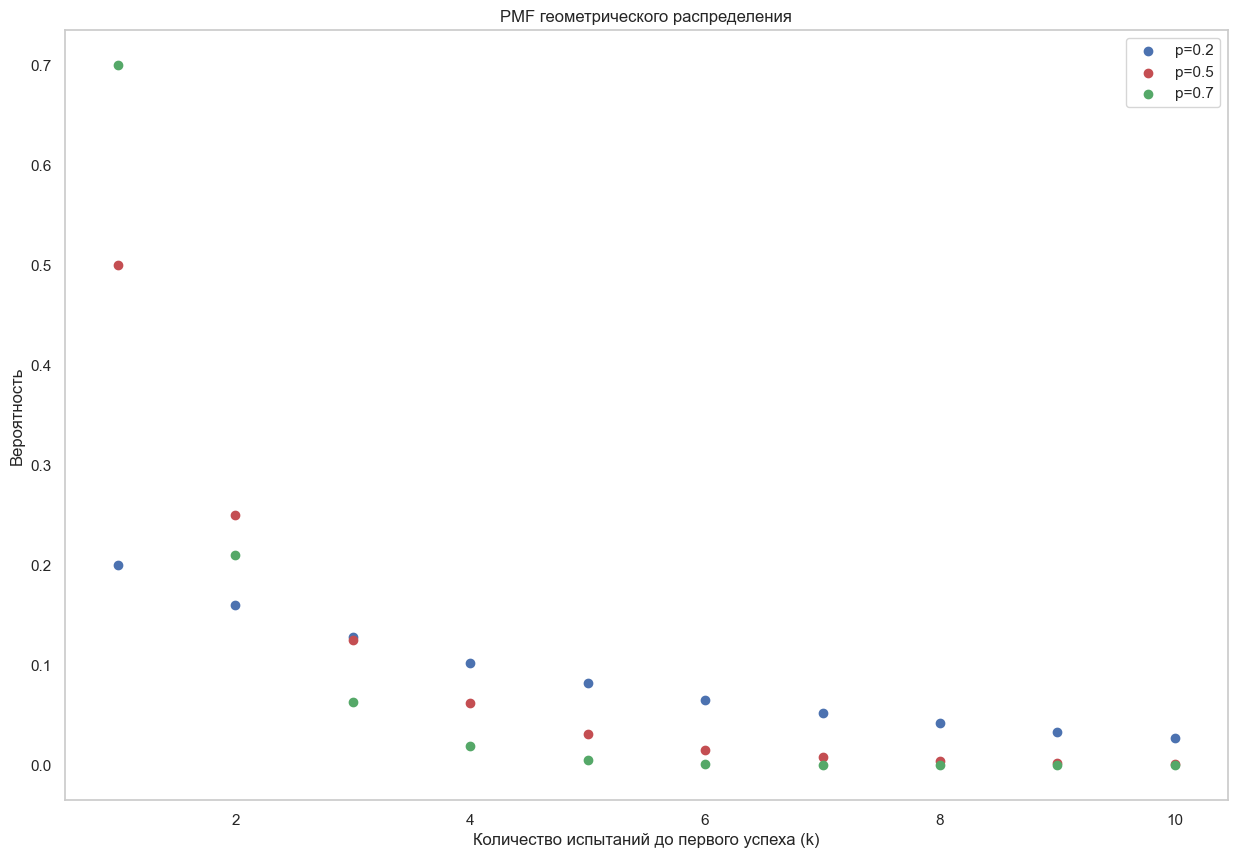

In [15]:
import numpy as np
from scipy.stats import geom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем параметры
p = 0.2
x = np.arange(1, 11)  # Значения от 1 до 10
plt.scatter(x, geom.pmf(x, p), c='b', label='p=0.2')

p = 0.5
plt.scatter(x, geom.pmf(x, p), c='r', label='p=0.5')

p = 0.7
plt.scatter(x, geom.pmf(x, p), c='g', label='p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF геометрического распределения")
plt.xlabel("Количество испытаний до первого успеха (k)")
plt.ylabel("Вероятность")
plt.show()

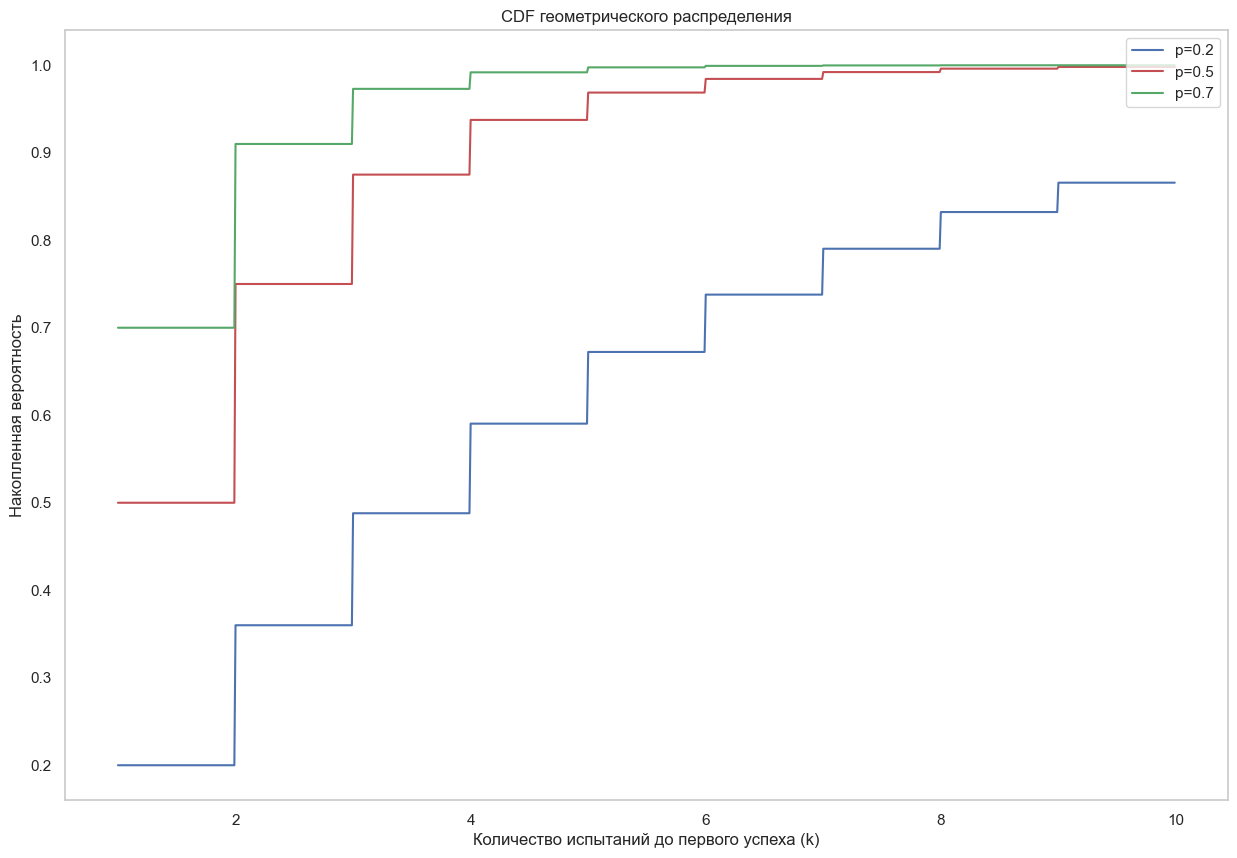

In [16]:
import numpy as np
from scipy.stats import geom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем параметры
p = 0.2
x = np.arange(1, 10, 0.01)
plt.plot(x, geom.cdf(x, p), c='b', label='p=0.2')

p = 0.5
plt.plot(x, geom.cdf(x, p), c='r', label='p=0.5')

p = 0.7
plt.plot(x, geom.cdf(x, p), c='g', label='p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("CDF геометрического распределения")
plt.xlabel("Количество испытаний до первого успеха (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

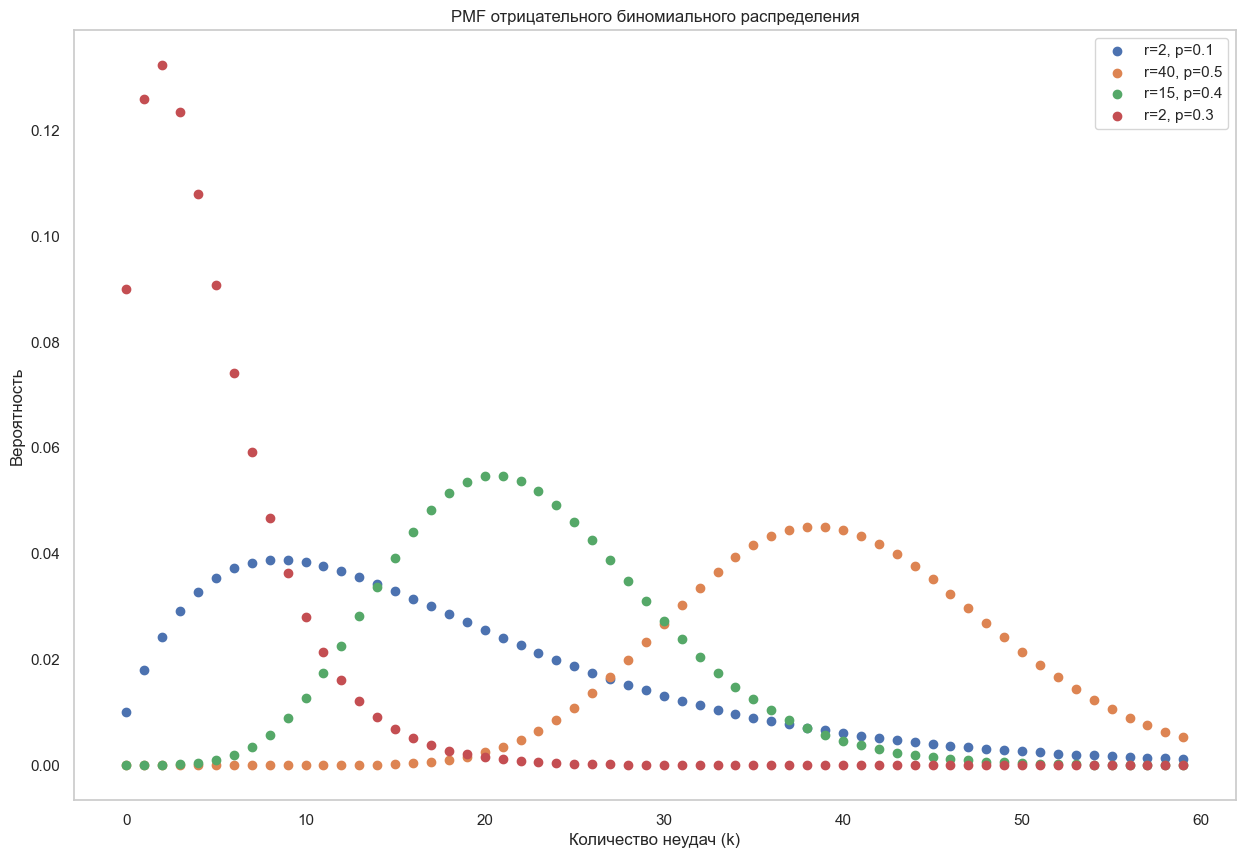

In [17]:
import numpy as np
from scipy.stats import nbinom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем параметры
n, p = 2, 0.1
x = np.arange(0, n * 30, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=2, p=0.1')

n, p = 40, 0.5
x = np.arange(0, n * 1.5, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=40, p=0.5')

n, p = 15, 0.4
x = np.arange(0, n * 4, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=15, p=0.4')

n, p = 2, 0.3
x = np.arange(0, n * 30, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=2, p=0.3')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF отрицательного биномиального распределения")
plt.xlabel("Количество неудач (k)")
plt.ylabel("Вероятность")
plt.show()

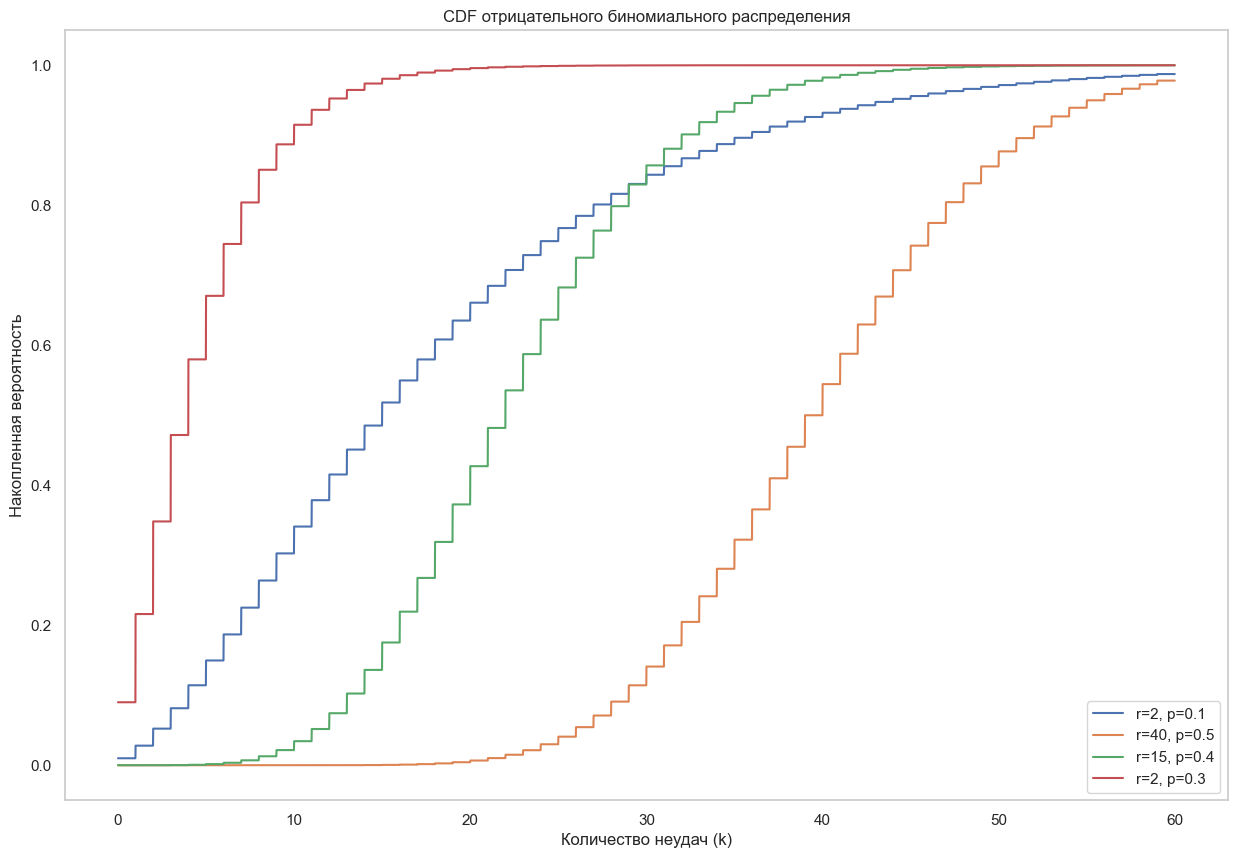

In [18]:
import numpy as np
from scipy.stats import nbinom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем параметры
n, p = 2, 0.1
x = np.arange(0, n * 30, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=2, p=0.1')

n, p = 40, 0.5
x = np.arange(0, n * 1.5, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=40, p=0.5')

n, p = 15, 0.4
x = np.arange(0, n * 4, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=15, p=0.4')

n, p = 2, 0.3
x = np.arange(0, n * 30, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=2, p=0.3')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower right')

# Отображаем график
plt.title("CDF отрицательного биномиального распределения")
plt.xlabel("Количество неудач (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

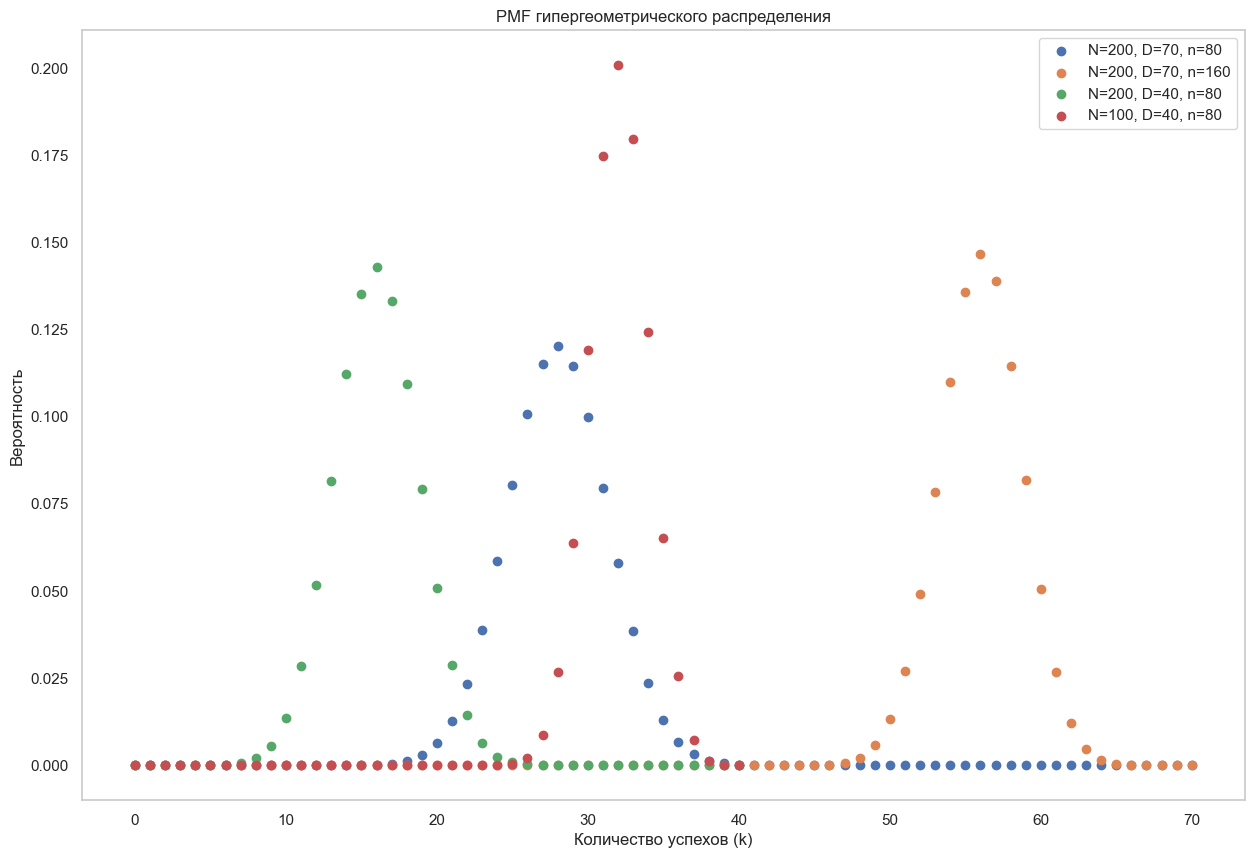

In [19]:
from scipy.stats import hypergeom
import matplotlib.pyplot as plt
import numpy as np

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем параметры
[M, n, N] = [200, 70, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.pmf(x), label='N=200, D=70, n=80')

[M, n, N] = [200, 70, 160]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.pmf(x), label='N=200, D=70, n=160')

[M, n, N] = [200, 40, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.pmf(x), label='N=200, D=40, n=80')

[M, n, N] = [100, 40, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.pmf(x), label='N=100, D=40, n=80')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF гипергеометрического распределения")
plt.xlabel("Количество успехов (k)")
plt.ylabel("Вероятность")
plt.show()

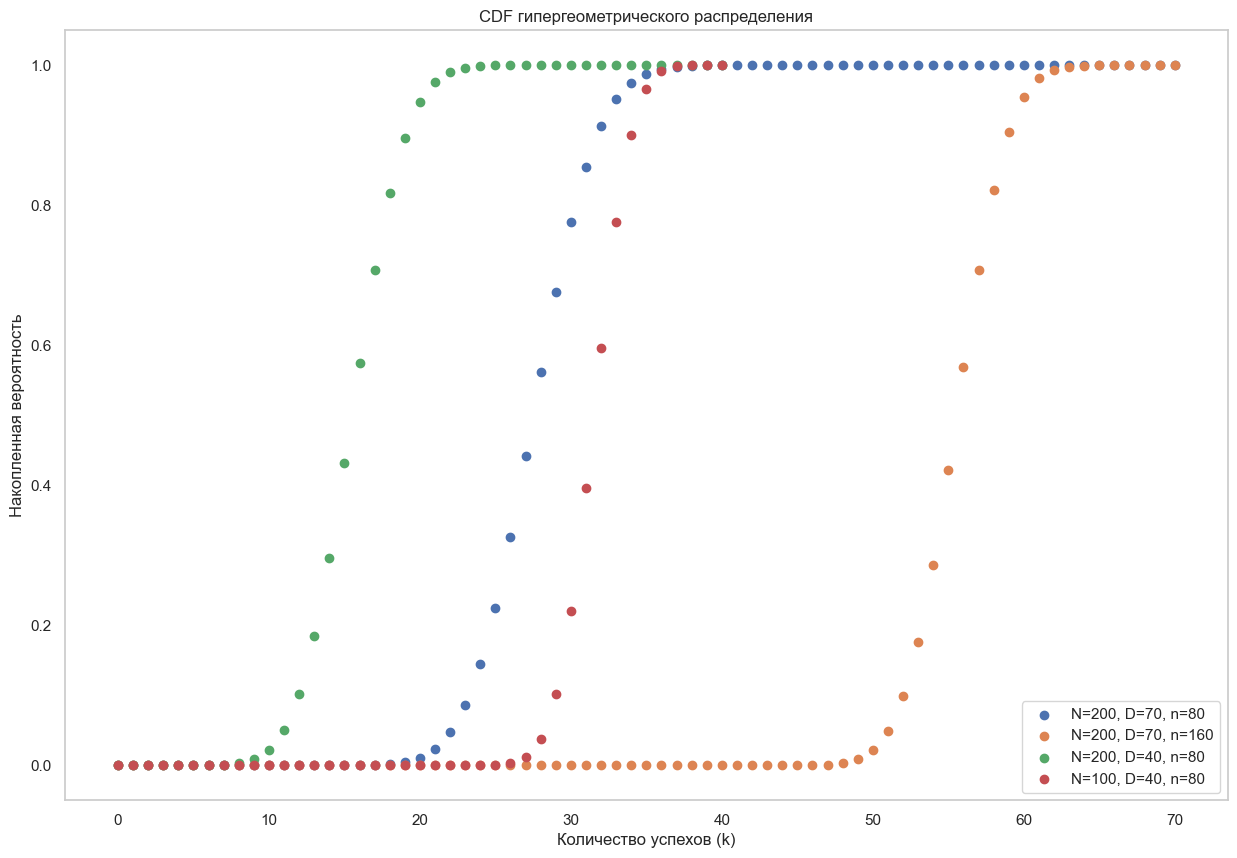

In [20]:
from scipy.stats import hypergeom
import matplotlib.pyplot as plt
import numpy as np

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем параметры
[M, n, N] = [200, 70, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.cdf(x), label='N=200, D=70, n=80')

[M, n, N] = [200, 70, 160]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.cdf(x), label='N=200, D=70, n=160')

[M, n, N] = [200, 40, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.cdf(x), label='N=200, D=40, n=80')

[M, n, N] = [100, 40, 80]
rv = hypergeom(M, n, N)
x = np.arange(0, n + 1)
plt.scatter(x, rv.cdf(x), label='N=100, D=40, n=80')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower right')

# Отображаем график
plt.title("CDF гипергеометрического распределения")
plt.xlabel("Количество успехов (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

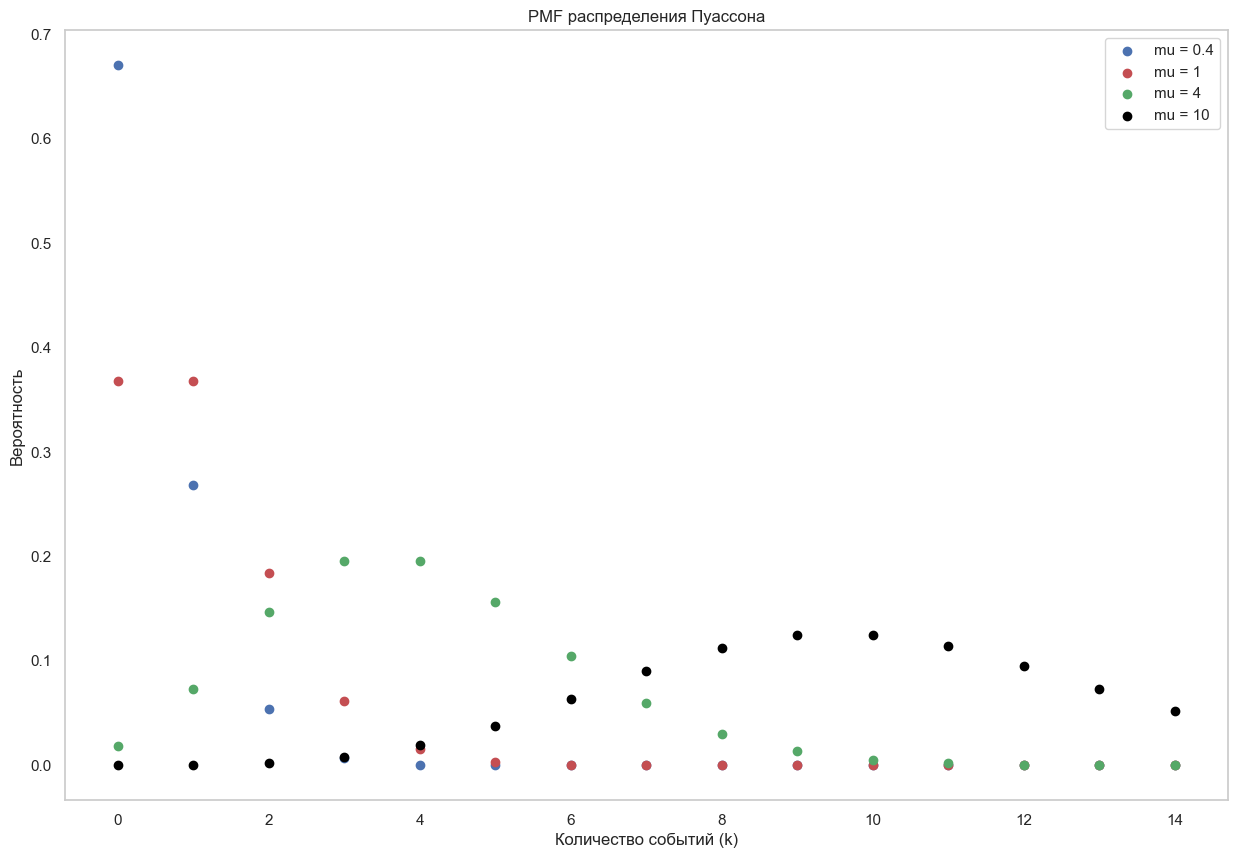

In [21]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем параметры
x = np.arange(0, 15, 1)
plt.scatter(x, poisson.pmf(x, 0.4), c='b', label='mu = 0.4')
plt.scatter(x, poisson.pmf(x, 1), c='r', label='mu = 1')
plt.scatter(x, poisson.pmf(x, 4), c='g', label='mu = 4')
plt.scatter(x, poisson.pmf(x, 10), c='black', label='mu = 10')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF распределения Пуассона")
plt.xlabel("Количество событий (k)")
plt.ylabel("Вероятность")
plt.show()

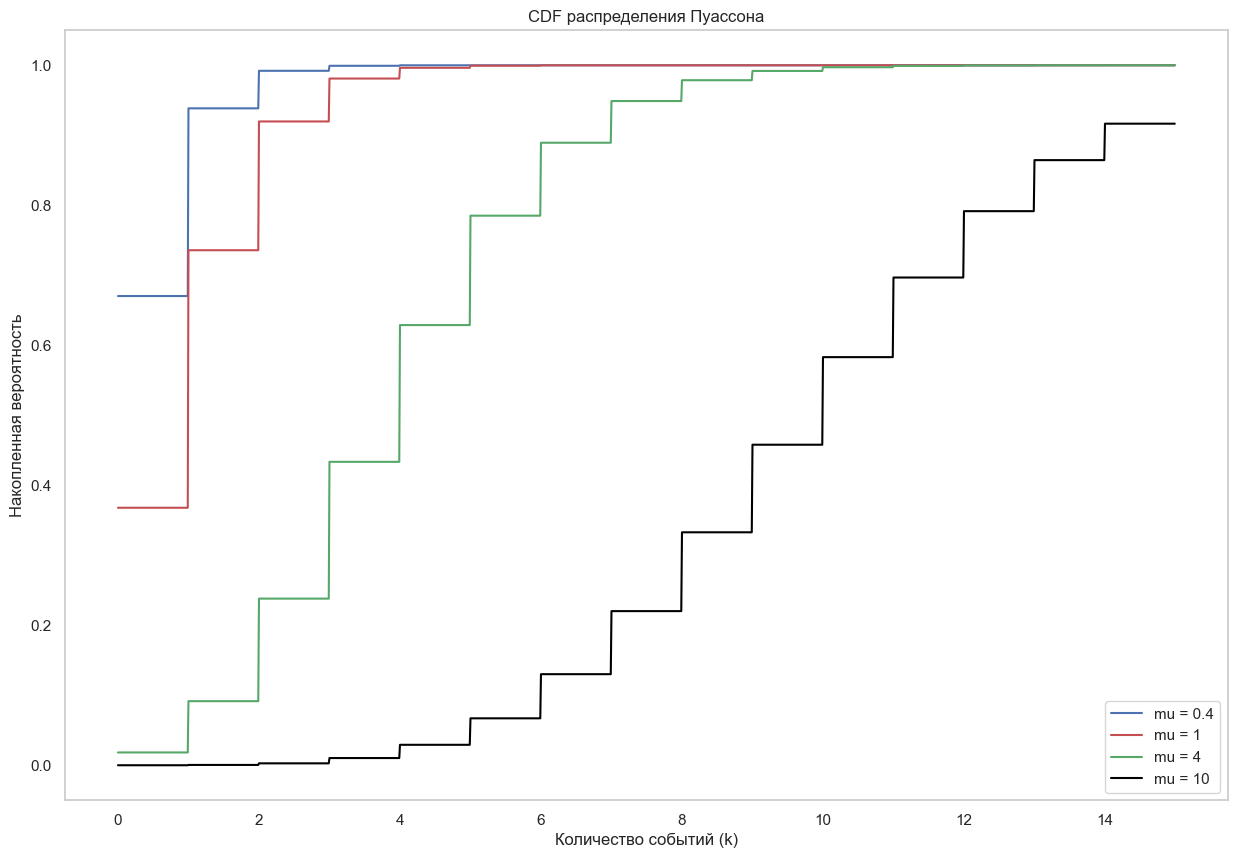

In [22]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(15, 10))

# Определяем параметры
x = np.arange(0, 15, 0.01)
plt.plot(x, poisson.cdf(x, 0.4), c='b', label='mu = 0.4')
plt.plot(x, poisson.cdf(x, 1), c='r', label='mu = 1')
plt.plot(x, poisson.cdf(x, 4), c='g', label='mu = 4')
plt.plot(x, poisson.cdf(x, 10), c='black', label='mu = 10')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower right')

# Отображаем график
plt.title("CDF распределения Пуассона")
plt.xlabel("Количество событий (k)")
plt.ylabel("Накопленная вероятность")
plt.show()